# IMPORTS

In [1]:
import os
import time
import json
import torch
import logging
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple
from datetime import timedelta

from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report, 
    confusion_matrix
)
from torch.utils.data import Dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed
)

import wandb

# Setup Logging & Reproducibility
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")

In [3]:
print(f"Kiến trúc GPU hiện tại: {torch.cuda.get_device_capability()}")
print(f"Danh sách kiến trúc PyTorch hỗ trợ: {torch.cuda.get_arch_list()}")

Kiến trúc GPU hiện tại: (7, 5)
Danh sách kiến trúc PyTorch hỗ trợ: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [4]:
wandb.login(key=wandb_api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lethanhthangdat (lethanhthangdat109) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# CONFIGURATIONS

In [5]:
# =============================================================================
# 1. CONFIGURATION
# =============================================================================
CONFIG = {
    "model_name":        "google-bert/bert-base-uncased",
    "train_path":        "/kaggle/input/datasets/lthnhthngt/cs114-clean/train_clean.parquet",
    "val_path":          "/kaggle/input/datasets/lthnhthngt/cs114-clean/val_clean.parquet",
    "test_path":         "/kaggle/input/datasets/lthnhthngt/cs114-clean/test_clean.parquet",
    
    "text_col":          "article",
    "label_col":         "label",
    "title_col":         "title",
    "class_names":       ["film", "culture_lifestyle", "sport", "music", "world_environment", "business_finance", "tech_science_games", "food"], 
    
    "max_seq_length":    512,
    "batch_size":        32,
    "epochs":            5,
    "learning_rate":     3e-5,
    "adam_epsilon":      1e-10,
    "adam_beta1":        0.9,
    "adam_beta2":        0.95,
    "weight_decay":      0.1,
    "warmup_ratio":      0.1,
    "label_smoothing_factor": 0.1,
    "lr_scheduler_type": "cosine", 
    "accumulation_steps": 4,
    
    "output_dir":        "/kaggle/working/checkpoints",
    "log_dir":           "/kaggle/working/logs",
    "fp16":              True,     
    "seed":              42,
    "early_stopping_patience": 2,
}

In [6]:
CONFIG["num_labels"] = len(CONFIG["class_names"])
CONFIG["id2label"] = {i: label for i, label in enumerate(CONFIG["class_names"])}
CONFIG["label2id"] = {label: i for i, label in enumerate(CONFIG["class_names"])}

In [7]:
set_seed(CONFIG["seed"])

# DATASET

In [8]:
# =============================================================================
# 2. DATASET PREPARATION
# =============================================================================
class NewsDataset(Dataset):
    def __init__(self, titles, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            titles, 
            texts, 
            truncation='only_second', 
            padding="max_length", 
            max_length=max_len,
            return_token_type_ids=True,
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

def load_and_preprocess_data(path, cfg):
    df = pd.read_parquet(path).dropna(subset=[cfg["text_col"], cfg["label_col"], cfg["title_col"]])
    titles = df[cfg["title_col"]].astype(str).tolist() 
    texts = df[cfg["text_col"]].astype(str).tolist()
    labels = df[cfg["label_col"]].map(cfg["label2id"]).astype(int).tolist()
    return titles, texts, labels

# METRICS

In [9]:
# =============================================================================
# 3. METRICS CALLBACK
# =============================================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

# TRAINING

In [10]:
tokenizer = BertTokenizerFast.from_pretrained(CONFIG["model_name"])

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/vocab.txt "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/vocab.txt "HTTP/1.1 200 OK"


vocab.txt: 0.00B [00:00, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer.json "HTTP/1.1 200 OK"


tokenizer.json: 0.00B [00:00, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/added_tokens.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/special_tokens_map.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"


In [11]:
# Load data
train_titles, train_texts, train_labels = load_and_preprocess_data(CONFIG["train_path"], CONFIG)
val_titles, val_texts, val_labels = load_and_preprocess_data(CONFIG["val_path"], CONFIG)
test_titles, test_texts, test_labels = load_and_preprocess_data(CONFIG["test_path"], CONFIG)

# Tạo dataset (Nhớ truyền đúng thứ tự tham số)
train_dataset = NewsDataset(train_titles, train_texts, train_labels, tokenizer, CONFIG["max_seq_length"])
val_dataset   = NewsDataset(val_titles, val_texts, val_labels, tokenizer, CONFIG["max_seq_length"])
test_dataset  = NewsDataset(test_titles, test_texts, test_labels, tokenizer, CONFIG["max_seq_length"])

In [12]:
# --- Initialize Model ---
model = BertForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=len(CONFIG["id2label"]),
    id2label=CONFIG["id2label"],
    label2id=CONFIG["label2id"]
)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/xet-read-token/86b5e0934494bd15c9632b12f734a8a67f723594 "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
# --- Training Arguments ---
training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"] * 2,
    
    learning_rate=CONFIG["learning_rate"],
    adam_epsilon=CONFIG["adam_epsilon"],
    adam_beta1=CONFIG["adam_beta1"],
    adam_beta2=CONFIG["adam_beta2"],
    weight_decay=CONFIG["weight_decay"],
    label_smoothing_factor=CONFIG["label_smoothing_factor"],
    lr_scheduler_type=CONFIG["lr_scheduler_type"],
    warmup_ratio=CONFIG["warmup_ratio"],
    gradient_accumulation_steps=CONFIG["accumulation_steps"],
    
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    
    logging_dir=CONFIG["log_dir"],
    logging_strategy="steps",
    logging_first_step=True,
    logging_steps=5,
    log_level="info",   

    fp16=CONFIG["fp16"],
    report_to="wandb",
    run_name="CS114_V4",
    
    dataloader_num_workers=os.cpu_count(),
    dataloader_pin_memory=True,
    disable_tqdm=False
)

# --- Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG["early_stopping_patience"])]
)

# --- TRAINING ---
print(f"\n🚀 Starting training with {CONFIG['lr_scheduler_type']} scheduler...")
start_train_time = time.time()
trainer.train()
total_train_time = time.time() - start_train_time
print(f"\n✅ Training complete! Total time: {timedelta(seconds=int(total_train_time))}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
***** Running training *****
  Num examples = 27,234
  Num Epochs = 5
  Instantaneous batch size per device = 32
  Training with DataParallel so batch size has been adjusted to: 64
  Total train batch size (w. parallel, distributed & accumulation) = 256
  Gradient Accumulation steps = 4
  Total optimization steps = 535
  Number of trainable parameters = 109,488,392



🚀 Starting training with cosine scheduler...


wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260510_184001-k0dsvaxx
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run CS114_V4
wandb: ⭐️ View project at https://wandb.ai/lethanhthangdat109/huggingface
wandb: 🚀 View run at https://wandb.ai/lethanhthangdat109/huggingface/runs/k0dsvaxx


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,5.651400,1.426436,0.893420,0.894152
2,5.112729,1.338299,0.911412,0.912085
3,4.690163,1.320301,0.914496,0.915319
4,4.518850,1.323783,0.916381,0.917214
5,3.942154,1.331520,0.917752,0.918509



***** Running Evaluation *****
  Num examples = 5836
  Batch size = 128
Saving model checkpoint to /kaggle/working/checkpoints/checkpoint-107
Configuration saved in /kaggle/working/checkpoints/checkpoint-107/config.json


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /kaggle/working/checkpoints/checkpoint-428/model.safetensors

***** Running Evaluation *****
  Num examples = 5836
  Batch size = 128
Saving model checkpoint to /kaggle/working/checkpoints/checkpoint-535
Configuration saved in /kaggle/working/checkpoints/checkpoint-535/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /kaggle/working/checkpoints/checkpoint-535/model.safetensors


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from /kaggle/working/checkpoints/checkpoint-535 (score: 0.9185090446463533).
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.


✅ Training complete! Total time: 2:07:05


In [14]:
final_model_path = os.path.join(CONFIG["output_dir"], "final_model")

trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"✅ Model và Tokenizer đã được lưu tại: {final_model_path}")

Saving model checkpoint to /kaggle/working/checkpoints/final_model
Configuration saved in /kaggle/working/checkpoints/final_model/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /kaggle/working/checkpoints/final_model/model.safetensors
tokenizer config file saved in /kaggle/working/checkpoints/final_model/tokenizer_config.json


✅ Model và Tokenizer đã được lưu tại: /kaggle/working/checkpoints/final_model


In [15]:
# --- INFERENCE & EVALUATION ON TEST SET ---
print("\n🔍 Running inference on test set...")
start_inf_time = time.time()
predictions = trainer.predict(test_dataset)
total_inf_time = time.time() - start_inf_time

avg_inf_latency = (total_inf_time / len(test_dataset)) * 1000 # ms per sample

y_preds = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids


***** Running Prediction *****
  Num examples = 5837
  Batch size = 128



🔍 Running inference on test set...


In [16]:
# =============================================================================
# 5. FINAL RESULTS & VISUALIZATION
# =============================================================================
print("\n" + "="*20 + " FINAL TEST RESULTS " + "="*20)
print(f"Total Training Time  : {timedelta(seconds=int(total_train_time))}")
print(f"Avg Inference Latency: {avg_inf_latency:.2f} ms/sample")
print("-" * 60)

# Classification Report
report = classification_report(
    y_true, y_preds, target_names=list(CONFIG["id2label"].values()), digits=4
)
print(report)


==================== FINAL TEST RESULTS ====================
Total Training Time  : 2:07:05
Avg Inference Latency: 16.57 ms/sample
------------------------------------------------------------
                    precision    recall  f1-score   support

              film     0.9211    0.9568    0.9386       879
 culture_lifestyle     0.8990    0.8212    0.8583       878
             sport     0.9812    0.9886    0.9849       792
             music     0.8739    0.9455    0.9083       770
 world_environment     0.9158    0.9017    0.9087       712
  business_finance     0.9351    0.8992    0.9168       625
tech_science_games     0.9171    0.9141    0.9156       617
              food     0.9617    0.9787    0.9701       564

          accuracy                         0.9239      5837
         macro avg     0.9256    0.9257    0.9252      5837
      weighted avg     0.9241    0.9239    0.9234      5837



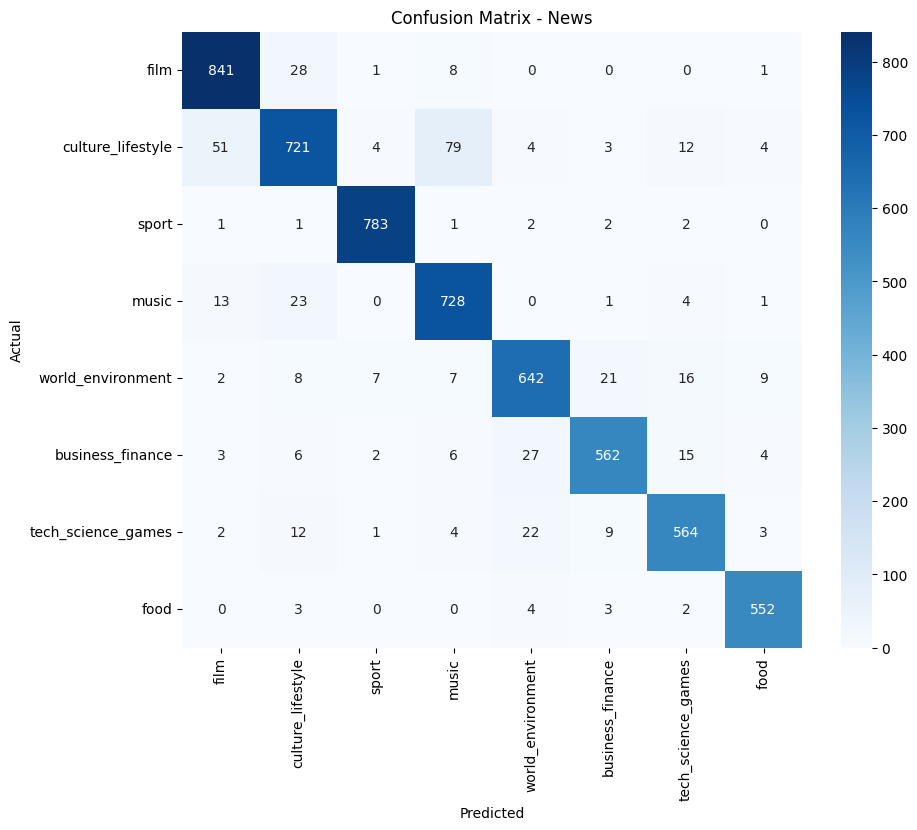

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CONFIG["id2label"].values(),
    yticklabels=CONFIG["id2label"].values()
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - News')
plt.savefig(f"{CONFIG['output_dir']}/confusion_matrix.png")
plt.show()

# Lưu kết quả ra file
with open(f"{CONFIG['output_dir']}/test_summary.json", "w") as f:
    json.dump({
        "train_time_sec": total_train_time,
        "avg_inference_latency_ms": avg_inf_latency,
        "test_accuracy": accuracy_score(y_true, y_preds),
        "test_f1_macro": f1_score(y_true, y_preds, average="macro")
    }, f, indent=4)